# M4A2 - GANs

> **Resumo:** GANs são um "jogo" entre dois modelos: um **Gerador**, que cria imagens a partir de ruído, e um **Discriminador**, que tenta distinguir real de falso. Treinando um contra o outro, o Gerador aprende a produzir dígitos do MNIST do zero. No fim, testamos o Discriminador num caso fora da distribuição (o Sonic).

> 📝 **Gerativo vs discriminativo:** classificadores (VGG, YOLO) aprendem a *fronteira* entre classes; modelos gerativos aprendem a *distribuição* dos dados e conseguem amostrar exemplos novos.

> ⚠️ **Use GPU!** Treinamos a GAN por 200 épocas no MNIST (+ 30 no FashionMNIST). No Colab: **Ambiente de execução → Alterar o tipo → GPU (T4)**. Em CPU levaria horas.

Na prática de hoje vamos treinar um modelo do tipo GAN utilizando [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Treinar Modelo
- Próximos passos
- ✅ Atividades Complementares (resolvidas)

---

## Introdução

### O que são Modelos Gerativos?
Conforme apresentado pelo professor nas primeiras aulas do módulo, a maior parte dos modelos clássicos de Visão Computacional que estudamos (como classificadores VGG/ResNet ou detectores YOLO) são **modelos discriminativos**: eles aprendem as fronteiras ou limites de decisão que separam classes de dados.

Os **modelos gerativos**, por outro lado, tentam aprender a **distribuição de probabilidade subjacente** dos dados reais. Dessa forma, eles conseguem amostrar novos pontos dessa distribuição e gerar dados completamente novos e inéditos (como imagens, áudio ou texto) que se parecem muito com os dados de treinamento originais.

### Comparação entre Abordagens Gerativas (VAEs vs GANs vs Difusão)

| Modelo | Arquitetura / Funcionamento | Vantagens | Limitações |
| :--- | :--- | :--- | :--- |
| **VAE** *(Autoencoders Variacionais)* | Codifica imagens para um espaço latente probabilístico contínuo (definido por parâmetros de média $\mu$ e variância $\sigma$) e reconstrói via Decoder. | Treinamento estável; espaço latente contínuo ideal para interpolação. | As imagens geradas tendem a ser borradas/desfocadas. |
| **GAN** *(Redes Adversárias Generativas)* | Jogo de soma zero (minimax) entre dois modelos: um **Gerador** (cria imagens a partir de ruído) e um **Discriminador** (classifica se a imagem é real ou falsa). | Imagens geradas com alto nível de nitidez e realismo. | Treinamento muito instável; propenso a *Mode Collapse* (gerar sempre a mesma imagem). |
| **Diffusion** *(Modelos de Difusão)* | Processo de destruição (adicionar ruído progressivo) e reconstrução (aprender a remover o ruído gaussiano passo a passo). | Qualidade de geração excepcional; alta estabilidade no treinamento. | Inferência lenta (requer dezenas de passos de denoising). |

### A Lógica Matemática da GAN (Minimax Game)
A competição entre o Gerador ($G$) e o Discriminador ($D$) é formulada matematicamente como um jogo minimax com a função de valor $V(D, G)$:

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

* O **Discriminador ($D$)** maximiza a probabilidade de atribuir o rótulo correto a imagens reais e geradas (quer que $D(x) \approx 1$ e $D(G(z)) \approx 0$).
* O **Gerador ($G$)** tenta minimizar a chance de $D$ detectar suas imagens geradas (quer que $D(G(z)) \approx 1$, ou seja, enganar o discriminador).

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [3]:
batch_size = 100

# MNIST Dataset.
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))])

train_dataset = torchvision.datasets.MNIST(root='./mnist_data/', train=True, transform=transform, download=True)
# Data Loader.
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.38MB/s]


## Treinar Modelo

Agora vamos criar os modelos e treinar ele.

In [4]:
########################
## Criando os modelos ##
########################


# Gerador.
class Generator(torch.nn.Module):
    def __init__(self, g_input_dim, g_output_dim):
        super(Generator, self).__init__()
        self.fc1 = torch.nn.Linear(g_input_dim, 256)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features*2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features*2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, g_output_dim)

    # método forward.
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        return torch.tanh(self.fc4(x))

# Discrimador.
class Discriminator(torch.nn.Module):
    def __init__(self, d_input_dim):
        super(Discriminator, self).__init__()
        self.fc1 = torch.nn.Linear(d_input_dim, 1024)
        self.fc2 = torch.nn.Linear(self.fc1.out_features, self.fc1.out_features//2)
        self.fc3 = torch.nn.Linear(self.fc2.out_features, self.fc2.out_features//2)
        self.fc4 = torch.nn.Linear(self.fc3.out_features, 1)

    # método forward.
    def forward(self, x):
        x = torch.nn.functional.leaky_relu(self.fc1(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc2(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        x = torch.nn.functional.leaky_relu(self.fc3(x), 0.2)
        x = torch.nn.functional.dropout(x, 0.3)
        return torch.sigmoid(self.fc4(x))

In [5]:
# Instanciar as redes.
z_dim = 100
mnist_dim = train_dataset.data.size(1) * train_dataset.data.size(2)  # 28*28 = 784

device = "cuda" if torch.cuda.is_available() else "cpu"
G = Generator(g_input_dim = z_dim, g_output_dim = mnist_dim).to(device)
D = Discriminator(mnist_dim).to(device)

In [6]:
# Função de perda.
criterion = torch.nn.BCELoss()

# Otimizador.
lr = 0.0002
G_optimizer = torch.optim.Adam(G.parameters(), lr = lr)
D_optimizer = torch.optim.Adam(D.parameters(), lr = lr)

In [7]:
def D_train(x):
    #=======================Treino do discriminador=======================#
    D.zero_grad()

    # Treina discriminador em dados reais.
    x_real, y_real = x.view(-1, mnist_dim), torch.ones(batch_size, 1)
    x_real, y_real = torch.autograd.Variable(x_real.to(device)), torch.autograd.Variable(y_real.to(device))

    D_output = D(x_real)
    D_real_loss = criterion(D_output, y_real)
    D_real_score = D_output

    # Treina discriminador em dados falsos.
    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    x_fake, y_fake = G(z), torch.autograd.Variable(torch.zeros(batch_size, 1).to(device))

    D_output = D(x_fake)
    D_fake_loss = criterion(D_output, y_fake)
    D_fake_score = D_output

    # Backpropagation e otimização dos parâmetros do discriminador.
    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_optimizer.step()

    return D_loss.data.item(), D_real_score.mean().item(), D_fake_score.mean().item()

def G_train(x):
    #=======================Treino do gerador=======================#
    G.zero_grad()

    z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    y = torch.autograd.Variable(torch.ones(batch_size, 1).to(device))

    G_output = G(z)
    D_output = D(G_output)
    G_loss = criterion(D_output, y)

    # Backpropagation e otimização dos parâmetros do gerador.
    G_loss.backward()
    G_optimizer.step()

    return G_loss.data.item()

In [8]:
# Laço de treino.
n_epoch = 200
print("Iniciando treinamento da GAN...")
for epoch in range(1, n_epoch+1):
    D_losses, G_losses = [], []
    D_real_scores, D_fake_scores = [], []
    for batch_idx, (x, _) in enumerate(train_loader):
        d_loss, d_real, d_fake = D_train(x)
        D_losses.append(d_loss)
        D_real_scores.append(d_real)
        D_fake_scores.append(d_fake)
        G_losses.append(G_train(x))

    if epoch == 1 or epoch % 10 == 0 or epoch == n_epoch:
        print('[%d/%d]: loss_d: %.3f, loss_g: %.3f | D(x): %.3f, D(G(z)): %.3f' % (
                epoch, n_epoch,
                torch.mean(torch.FloatTensor(D_losses)),
                torch.mean(torch.FloatTensor(G_losses)),
                torch.mean(torch.FloatTensor(D_real_scores)),
                torch.mean(torch.FloatTensor(D_fake_scores))
        ))

Iniciando treinamento da GAN...
[1/200]: loss_d: 1.035, loss_g: 2.158 | D(x): 0.728, D(G(z)): 0.378
[10/200]: loss_d: 0.706, loss_g: 2.098 | D(x): 0.786, D(G(z)): 0.227
[20/200]: loss_d: 0.878, loss_g: 1.702 | D(x): 0.720, D(G(z)): 0.287
[30/200]: loss_d: 1.014, loss_g: 1.391 | D(x): 0.667, D(G(z)): 0.338
[40/200]: loss_d: 1.116, loss_g: 1.160 | D(x): 0.623, D(G(z)): 0.379
[50/200]: loss_d: 1.163, loss_g: 1.089 | D(x): 0.605, D(G(z)): 0.398
[60/200]: loss_d: 1.183, loss_g: 1.055 | D(x): 0.595, D(G(z)): 0.406
[70/200]: loss_d: 1.226, loss_g: 0.976 | D(x): 0.577, D(G(z)): 0.423
[80/200]: loss_d: 1.242, loss_g: 0.958 | D(x): 0.570, D(G(z)): 0.429
[90/200]: loss_d: 1.262, loss_g: 0.922 | D(x): 0.561, D(G(z)): 0.438
[100/200]: loss_d: 1.256, loss_g: 0.925 | D(x): 0.565, D(G(z)): 0.436
[110/200]: loss_d: 1.272, loss_g: 0.903 | D(x): 0.557, D(G(z)): 0.443
[120/200]: loss_d: 1.271, loss_g: 0.901 | D(x): 0.557, D(G(z)): 0.443
[130/200]: loss_d: 1.276, loss_g: 0.896 | D(x): 0.556, D(G(z)): 0.444

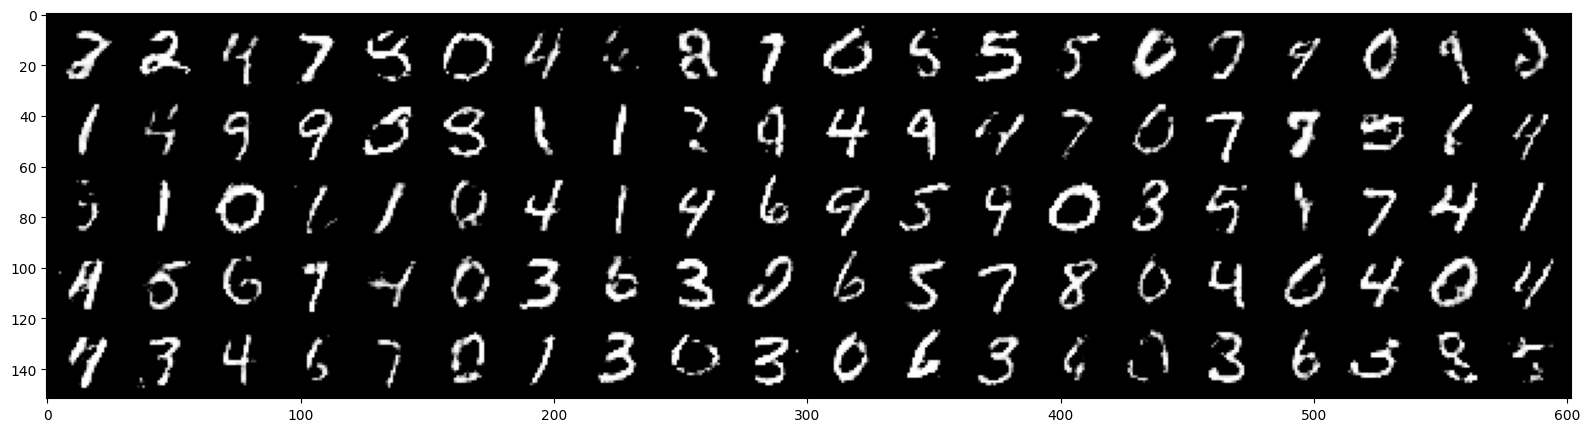

In [9]:
# Inferência com modelo treinado.
with torch.no_grad():
    test_z = torch.autograd.Variable(torch.randn(batch_size, z_dim).to(device))
    generated = G(test_z)

generated = generated.view(generated.size(0), 1, 28, 28)
grid = torchvision.utils.make_grid(generated.cpu(), 20)
grid = grid.permute(1, 2, 0).numpy()
plt.figure(figsize=(20, 5))
plt.imshow(grid.squeeze(), cmap='gray')

Text(0.5, 1.0, 'Real (MNIST)')

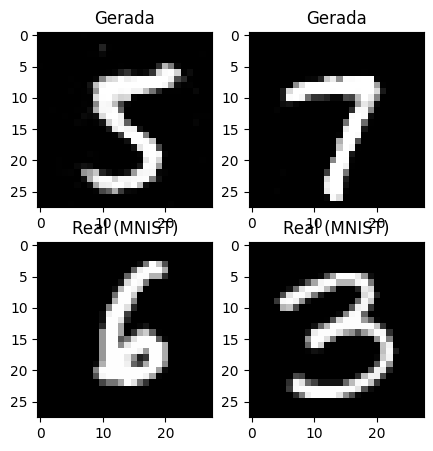

In [10]:
# Comparação resultados dos modelos e dados da base.
indexes_gen = [np.random.randint(0, batch_size), np.random.randint(0, batch_size)]
indexes_data = [np.random.randint(0, len(train_dataset)), np.random.randint(0, len(train_dataset))]

index = 0

gen_imgs = generated.view(generated.size(0), 1, 28, 28).cpu().numpy()
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
axes[0, 0].imshow(gen_imgs[indexes_gen[0]].squeeze(), cmap="gray")
axes[0, 0].set_title("Gerada")
axes[0, 1].imshow(gen_imgs[indexes_gen[1]].squeeze(), cmap="gray")
axes[0, 1].set_title("Gerada")
axes[1, 0].imshow(train_dataset[indexes_data[0]][0].squeeze().numpy(), cmap="gray")
axes[1, 0].set_title("Real (MNIST)")
axes[1, 1].imshow(train_dataset[indexes_data[1]][0].squeeze().numpy(), cmap="gray")
axes[1, 1].set_title("Real (MNIST)")

## Próximos Passos e Referências

Nas próximas práticas vamos trabalhar com problemas reais que envolvem Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://github.com/lyeoni/pytorch-mnist-GAN
- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares

Nesta seção, realizamos as atividades propostas:
1. **Mudança de base de dados para o FashionMNIST** (geração de imagens de roupas e calçados).
2. **Exploração de novos hiperparâmetros** (alteração do tamanho do lote para 128 e do número de épocas para 30).
3. **Teste do Discriminador no "Team Sonic"**: redimensionamos a imagem do Sonic para 28x28 em tons de cinza e avaliamos com o discriminador treinado para verificar se ele a classifica como real (dígito manuscrito) ou falsa.

### 1 e 2. Treinamento da GAN no FashionMNIST com Novos Hiperparâmetros

Vamos carregar o FashionMNIST, criar novas instâncias do Gerador e Discriminador, e treiná-los por 30 épocas com batch size de 128.

In [11]:
# Hiperparâmetros alternativos
batch_size_fashion = 128
epochs_fashion = 30
lr_fashion = 0.0002

# Carregar FashionMNIST
transform_fashion = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5), std=(0.5))
])

fashion_dataset = torchvision.datasets.FashionMNIST(root='./fashion_data/', train=True, transform=transform_fashion, download=True)
fashion_loader = torch.utils.data.DataLoader(dataset=fashion_dataset, batch_size=batch_size_fashion, shuffle=True, num_workers=0)

# Classes do FashionMNIST para referência
fashion_classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"FashionMNIST carregado: {len(fashion_dataset)} imagens de treino.")

# Instanciar novos modelos
G_fashion = Generator(g_input_dim=z_dim, g_output_dim=mnist_dim).to(device)
D_fashion = Discriminator(mnist_dim).to(device)

G_fashion_opt = torch.optim.Adam(G_fashion.parameters(), lr=lr_fashion)
D_fashion_opt = torch.optim.Adam(D_fashion.parameters(), lr=lr_fashion)

# Funções de auxílio para o treino no FashionMNIST
def D_train_fashion(x):
    D_fashion.zero_grad()
    x_real = x.view(-1, mnist_dim).to(device)
    y_real = torch.ones(x.size(0), 1).to(device)

    D_output = D_fashion(x_real)
    D_real_loss = criterion(D_output, y_real)

    z = torch.randn(x.size(0), z_dim).to(device)
    x_fake = G_fashion(z)
    y_fake = torch.zeros(x.size(0), 1).to(device)

    D_output = D_fashion(x_fake)
    D_fake_loss = criterion(D_output, y_fake)

    D_loss = D_real_loss + D_fake_loss
    D_loss.backward()
    D_fashion_opt.step()
    return D_loss.item()

def G_train_fashion(x):
    G_fashion.zero_grad()
    z = torch.randn(x.size(0), z_dim).to(device)
    y = torch.ones(x.size(0), 1).to(device)

    G_output = G_fashion(z)
    D_output = D_fashion(G_output)
    G_loss = criterion(D_output, y)

    G_loss.backward()
    G_fashion_opt.step()
    return G_loss.item()

# Laço de treinamento
print("Iniciando treinamento no FashionMNIST (30 épocas)...")
for epoch in range(1, epochs_fashion + 1):
    D_losses, G_losses = [], []
    for x, _ in fashion_loader:
        D_losses.append(D_train_fashion(x))
        G_losses.append(G_train_fashion(x))

    if epoch == 1 or epoch % 5 == 0 or epoch == epochs_fashion:
        print('[Fashion Época %d/%d]: loss_d: %.3f, loss_g: %.3f' % (
            epoch, epochs_fashion, np.mean(D_losses), np.mean(G_losses)))

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.3MB/s]


FashionMNIST carregado: 60000 imagens de treino.
Iniciando treinamento no FashionMNIST (30 épocas)...
[Fashion Época 1/30]: loss_d: 0.755, loss_g: 2.749
[Fashion Época 5/30]: loss_d: 0.333, loss_g: 3.821
[Fashion Época 10/30]: loss_d: 0.625, loss_g: 2.579
[Fashion Época 15/30]: loss_d: 0.682, loss_g: 2.173
[Fashion Época 20/30]: loss_d: 0.786, loss_g: 1.913
[Fashion Época 25/30]: loss_d: 0.875, loss_g: 1.637
[Fashion Época 30/30]: loss_d: 0.918, loss_g: 1.552


#### Geração de Amostras - FashionMNIST

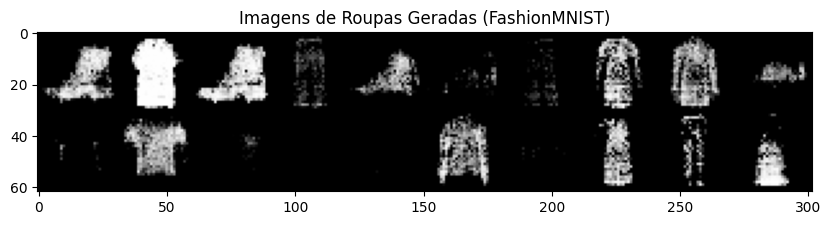

In [12]:
# Gerar imagens com a GAN treinada no FashionMNIST
with torch.no_grad():
    test_z_fashion = torch.randn(20, z_dim).to(device)
    generated_fashion = G_fashion(test_z_fashion)

generated_fashion = generated_fashion.view(generated_fashion.size(0), 1, 28, 28)
grid_fashion = torchvision.utils.make_grid(generated_fashion.cpu(), 10)
grid_fashion = grid_fashion.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 5))
plt.imshow(grid_fashion.squeeze(), cmap='gray')
plt.title("Imagens de Roupas Geradas (FashionMNIST)")
plt.show()

### 3. Avaliando o "Team Sonic" com o Discriminador MNIST

Vamos passar a imagem do Sonic pelo discriminador treinado no MNIST. Como a imagem do Sonic é colorida e grande, nós:
1. Carregamos a imagem do Sonic.
2. Convertemos para tons de cinza.
3. Redimensionamos para 28x28 pixels.
4. Normalizamos no mesmo intervalo $[-1, 1]$ das imagens de treinamento.
5. Avaliamos a probabilidade de ser "real" (ou seja, um dígito real manuscrito).

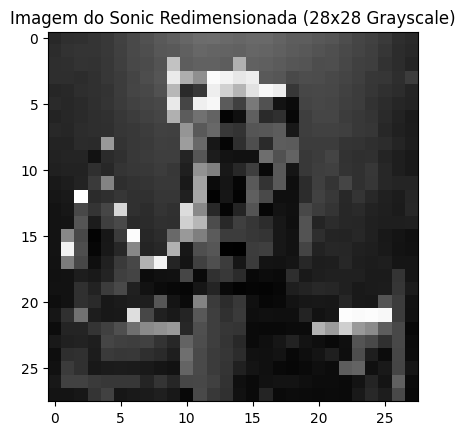

Resultado do Discriminador MNIST para o Sonic: 0.861994% de probabilidade de ser Real

✅ O discriminador identificou corretamente que o Sonic NÃO pertence à distribuição de dígitos manuscritos do MNIST.


In [13]:
import cv2
import os

# Procurar imagem do Sonic
sonic_path = "/content/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "../../img/sonic.jpg"
if not os.path.exists(sonic_path):
    sonic_path = "img/sonic.jpg"

if not os.path.exists(sonic_path):
    print("ERRO: Imagem do Sonic não encontrada!")
else:
    # 1. Ler imagem e converter para escala de cinza
    img_bgr = cv2.imread(sonic_path)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 2. Redimensionar para 28x28 (resolução MNIST)
    img_resized = cv2.resize(img_gray, (28, 28))

    # 3. Pré-processar: converter para tensor e normalizar (valores entre -1 e 1)
    img_tensor = torch.FloatTensor(img_resized) / 255.0
    img_normalized = (img_tensor - 0.5) / 0.5
    img_flat = img_normalized.view(-1, 28 * 28).to(device)

    # Visualizar a imagem de entrada 28x28
    plt.imshow(img_resized, cmap='gray')
    plt.title("Imagem do Sonic Redimensionada (28x28 Grayscale)")
    plt.show()

    # 4. Passar pelo discriminador treinado no MNIST
    D.eval()
    with torch.no_grad():
        score = D(img_flat).item()

    print(f"Resultado do Discriminador MNIST para o Sonic: {score * 100:.6f}% de probabilidade de ser Real")
    print()
    if score > 0.5:
        print("💡 O discriminador foi enganado e considerou a imagem do Sonic como um dígito real!")
    else:
        print("✅ O discriminador identificou corretamente que o Sonic NÃO pertence à distribuição de dígitos manuscritos do MNIST.")